#Exam 2

##1. Gather the table on 8000 km mountains from the wikipedia page

In [ ]:
!pip install google-colab-selenium

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pa

url = "https://en.wikipedia.org/wiki/List_of_mountains_by_elevation"

r = requests.get(url)
soup = BeautifulSoup(r.text)

soup.find_all('table')

[]

In [ ]:

from selenium.webdriver.chrome.options import Options
import google_colab_selenium as gs

custom_options = Options()
custom_options.add_argument("--headless")
# Add your custom options here

driver = gs.Chrome(options=custom_options)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Store the data as a pandas dataframe.

In [ ]:
from io import StringIO

driver.get(url)
soup = BeautifulSoup(driver.page_source, 'html.parser')
tables = soup.find_all('table')
#tables
pa.read_html(StringIO(str(tables[0])))[0]

,Mountain,Metres,Feet,Range,Location and notes
0,Mount Everest,8848,29029,Himalayas,Nepal/China
1,K2,8611,28251,Karakoram,Pakistan/China
2,Kangchenjunga,8586,28169,Himalayas,Nepal/India
3,Lhotse,8516,27940,Himalayas,Nepal – Climbers ascend Lhotse Face in climbin...
4,Makalu,8485,27838,Himalayas,Nepal
5,Cho Oyu,8188,26864,Himalayas,"Nepal – Considered ""easiest"" eight-thousander"
6,Dhaulagiri,8167,26795,Himalayas,Nepal – Presumed world's highest from 1808-1838
7,Manaslu,8163,26781,Himalayas,Nepal
8,Nanga Parbat,8126,26660,Himalayas,Pakistan
9,Annapurna,8091,26545,Himalayas,Nepal – First eight-thousander to be climbed (...


Nothing new, just went back to my github to get the code for this one.

###Create a barchart of the Ranges. This will just be a count of how many mountains in each range are in the table.

<Axes: xlabel='Range'>

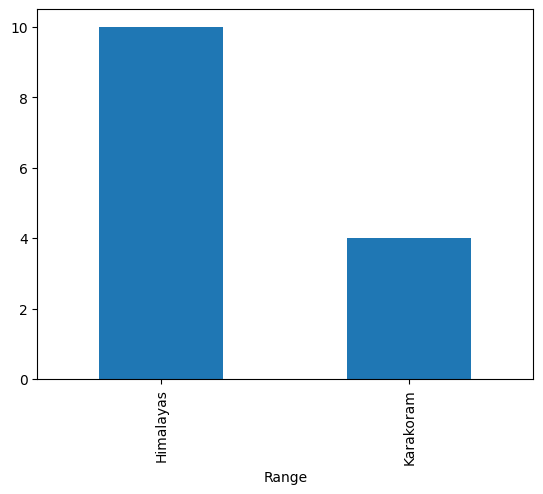

In [ ]:
df = pa.read_html(StringIO(str(tables[0])))[0]
df.groupby('Range')['Mountain'].count().plot(kind = "bar")

10 Himalayas and 4 in Karakoram

###Create a box-plot of the height in Feet.

<Axes: >

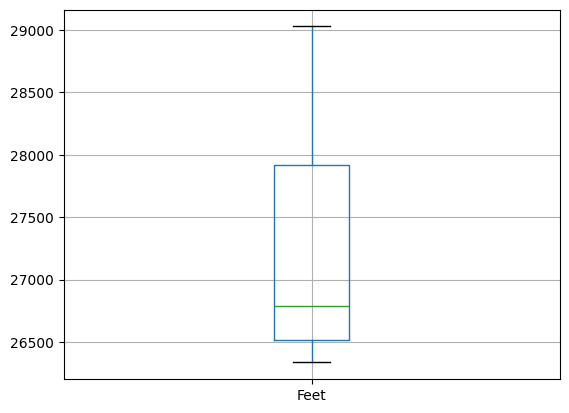

In [ ]:
df.boxplot(column='Feet')

Thats interesting there are no outliers. but the median is really close to the bottom of the graph rather than the middle so thats kinda interesting.

###Report the mean, standard deviation and five number summary of the height in Feet.

In [ ]:
df['Feet'].describe()

,Feet
count,14.000000
mean,27178.071429
std,879.431063
min,26335.000000
25%,26518.750000
50%,26788.000000
75%,27914.500000
max,29029.000000


I typed in df.feet(mean) and it gave me an error and hit explain error and gemeni came up with this. I didnt know that .describe() was a thing but that seems really useful especially in stats if we used python in that class.

###Report the mean and median of mountains when grouped by their Range.

In [ ]:
print("Mean (in ft) Grouped by")
print(df.Feet.groupby(df['Range']).mean())
print("\nMedian (in ft) Grouped by")
print(df.Feet.groupby(df['Range']).median())

Mean (in ft) Grouped by
Range
Himalayas    27295.60
Karakoram    26884.25
Name: Feet, dtype: float64

Median (in ft) Grouped by
Range
Himalayas    26829.5
Karakoram    26462.0
Name: Feet, dtype: float64


It looks like for Karakoram the mean is pretty close to its median value but the himalayas has a difference of about 1000ft

In [ ]:
driver.quit()

##2. Use BigQuery public dataset ‘chicago taxi trips.taxi trips’ using the Colab and SQL interface.

In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


###How many rows are in the dataset?

In [ ]:
%%bigquery --project msimpson
SELECT
  COUNT(*) as total_rows
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`

Query is running:   0%|          |

Downloading:   0%|          |

,total_rows
0,211655459


There are 211,655,459 rows in this data set

###What is the average trip miles based on payment type?

In [ ]:
%%bigquery --project msimpson
SELECT *
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
LIMIT 5

Query is running:   0%|          |

Downloading:   0%|          |

,unique_key,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_latitude,pickup_longitude,pickup_location,dropoff_latitude,dropoff_longitude,dropoff_location
0,213d2720f44959471196ae1115c312bb878858c5,d72104d59ef45d3ecb85925a234e9366c59ab32d9751d1...,2016-10-19 18:45:00+00:00,2016-10-19 19:00:00+00:00,900,4.1,<NA>,<NA>,<NA>,<NA>,...,1.0,15.00,Cash,City Service,NaN,NaN,None,NaN,NaN,None
1,7b90937f0ed598da7d50a9a6c5043c84fd27fd56,d72104d59ef45d3ecb85925a234e9366c59ab32d9751d1...,2016-10-19 19:15:00+00:00,2016-10-19 19:30:00+00:00,480,1.6,<NA>,<NA>,<NA>,<NA>,...,1.0,12.25,Credit Card,City Service,NaN,NaN,None,NaN,NaN,None
2,1fefb85bf9b3de303a80b100628a7dfea15e45de,d72104d59ef45d3ecb85925a234e9366c59ab32d9751d1...,2016-10-19 19:30:00+00:00,2016-10-19 19:30:00+00:00,360,0.8,<NA>,<NA>,<NA>,<NA>,...,1.0,9.25,Credit Card,City Service,NaN,NaN,None,NaN,NaN,None
3,8559c8381ee92e2e1a8d8c76d063728d8d26d6bc,d72104d59ef45d3ecb85925a234e9366c59ab32d9751d1...,2016-10-19 19:45:00+00:00,2016-10-19 20:00:00+00:00,600,2.0,<NA>,<NA>,<NA>,<NA>,...,1.0,10.00,Cash,City Service,NaN,NaN,None,NaN,NaN,None
4,574136041a006a4f958e571ff2a0931423e1045c,d72104d59ef45d3ecb85925a234e9366c59ab32d9751d1...,2016-10-19 20:00:00+00:00,2016-10-19 20:00:00+00:00,0,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,3.25,Cash,City Service,NaN,NaN,None,NaN,NaN,None


I lowkey misread this and thought it said "based on permanent type" and I was like what is my professor on about??

In [ ]:
%%bigquery --project msimpson
SELECT payment_type, AVG(trip_miles) as avg_miles
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
GROUP BY payment_type

Query is running:   0%|          |

Downloading:   0%|          |

,payment_type,avg_miles
0,Dispute,3.289322
1,Mobile,4.048919
2,Cash,2.765573
3,Credit Card,4.364340
4,Unknown,4.096302
5,Way2ride,3.747887
6,No Charge,2.021469
7,Prcard,7.545511
8,Split,4.388640
9,Pcard,2.443684


I wonder why there are so many prepaid card types and what they mean. Is it a prepaid card as in one they got from their bank that works like a debit card just with a limited amount of money? or is it a prepaid card for just the taxi service? If so maybe thats why the prepaid cards have such a higher average.

###How many fares, that had a non-zero recorded fare, were above the average fare?

In [ ]:
%%bigquery --project msimpson

SELECT AVG(fare) as avg_fare
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE fare > 0

Query is running:   0%|          |

Downloading:   0%|          |

,avg_fare
0,13.824687


In [ ]:
%%bigquery --project msimpson

SELECT COUNT(fare) as fare_count, AVG(fare) as avg_fare
FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
WHERE fare > 0 AND fare > (SELECT AVG(fare) FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`)
GROUP BY fare

Query is running:   0%|          |

Downloading:   0%|          |

,fare_count,avg_fare
0,763,13.91
1,613,14.38
2,368321,14.65
3,769,15.30
4,310615,15.45
...,...,...
22023,2,157.18
22024,1,9500.55
22025,1,4000.33
22026,1,587.50


I chose to group it by fare because its a lot more interesting than just looking at the total number of fares above the average of the average. Average am i right? if you wanted the boring one i guess you can put a hashtag on the last line.

##3. Questions about the exam

###Approximately how long did you work on this exam?

Its taken me about 2 hours and 45 minutes as of answering this question but Im also watching OKC blow out the LA Lakers on my other monitor we are currently up 40

###Which was the hardest and easiest topic from this section?

I think the easiest one was just the SQL count one but I also think the hardest one was the SQL one where you had to get the values above average it took me a bit.

###Which method of gathering data are you most excited to use again?

The method I liked the most was the stuff using selenium and grabbing the data from websites I think that it can actually be useful and Its kinda fun because its like programming a macro to go through and grab data for you.

##4. Documentation of Resources

###Show any queries made to LLM (AI, chatGPT, gemini, etc.). (not to be used for your responses to graphics!)

I actually didnt really use any prompts for this one, I know on a couple of them It autocorrected the the code I was wanting so I'm not sure if I would count that since I was going to count it anyways. The one where I did use it was df['Feet'].describe() I wrote some code that I thought was pretty close to what I wanted and then hit explain error and it gave me this and I didnt even know describe was a function but it answered the question perfectly.

###Detail responses and show what was accepted or rejected.

I didnt delete anything but on the taxi one I misread what the question was asking for so I had to pull up the whole table and see if I could figure out what you were talking about and then when I saw the comlumn on the table it clicked that I read the question wrong. Also I guess I accepted the group by fare on the question about the above average fares because I thought the way I had it showed a lot cooler information than just one row on the table.

###Give any outside resources that were not from LLM.

I used my github and your github from previous assignments and previous classes to use as reference when writing my code for this exam.

###Include the statement asked for in the directions.

Done.